## **load data**

In [3]:
import sys
import sklearn
import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from functools import partial
import PIL
import PIL.Image

import torch


In [2]:
!pip install torch

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/113.8 MB ? eta -:--:--
   - -------------------------------------- 5.5/113.8 MB 28.5 MB/s eta 0:00:04
   ---- ----------------------------------- 12.3/113.8 MB 30.4 MB/s eta 0:00:04
   ------ --------------------------------- 19.7/113.8 MB 31.7 MB/s eta 0:00:03
   --------- ------------------------------ 26.2/113.8 MB 32.0 MB/s eta 0:00:03
   ----------- ---------------------------- 31.7/113.8 MB 31.2 MB/s eta 0:00:03
   ------------ --------------------------- 36.4/113.8 MB 29.5 MB/s eta 0:00:03
   -------------- ------------------------- 41.9/113.8 MB 29.0 MB/s eta 0:00:03
   ---------------- ----------------------- 46.9/113.8 MB 28.3 MB/s eta 0:00:03
   ------------------ --------------------- 51.6/113.8 MB 27.7 MB/s eta 0:00:03
   -------------------- ------------------- 57.1/113.8 MB 27.4 MB/s eta 0:00:03
   --------------------- ------------------ 61.9/113


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\school\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
from sklearn.datasets import load_files

data_dir = "images_original/"
batch_size = 32;
# IMPORTANT: Depends on what pre-trained model you choose, you will need to change these dimensions accordingly
img_height = 64;
img_width = 64;


In [6]:
!pip install torchvision

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/4.3 MB ? eta -:--:--
   -------------------------- ------------- 2.9/4.3 MB 23.1 MB/s eta 0:00:01
   ---------------------------------------- 4.3/4.3 MB 18.5 MB/s  0:00:00



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\school\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [8]:
from torch import manual_seed as torch_manual_seed
import random
import numpy as np

from torch.cuda import max_memory_allocated, set_device, manual_seed_all
from torch.backends import cudnn

def setup_seed(seed):
    torch_manual_seed(seed)
    manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    cudnn.deterministic = True

SEED = 42
setup_seed(SEED)

In [9]:
from torch.utils.data import DataLoader, random_split
from torch import Generator
from torchvision.transforms import ToTensor
from torchvision.datasets import ImageFolder


TEST_RATIO = 0.2
BATCH_SIZE = 32

# Download and load the training data
dataset_all = ImageFolder(
    data_dir,
    transform=ToTensor(),
)

size_all = len(dataset_all)
print(f'Before splitting the full dataset into train and test: len(dataset_all)={size_all}')


size_test = int(size_all * TEST_RATIO)
size_train = size_all - size_test

dataset_train, dataset_test = random_split(dataset_all, [size_train, size_test], generator=Generator().manual_seed(SEED))
print(f'After splitting the full dataset into train and test: len(dataset_train)={len(dataset_train)}. len(dataset_test)={len(dataset_test)}')

# NOTE that you must not use the test dataset for model selection


Before splitting the full dataset into train and test: len(dataset_all)=999
After splitting the full dataset into train and test: len(dataset_train)=800. len(dataset_test)=199


In [10]:
from torch.utils.data import DataLoader, random_split
from torch import Generator
from torchvision.transforms import ToTensor
from torchvision.datasets import ImageFolder


TEST_RATIO = 0.2
BATCH_SIZE = 32

# Download and load the training data
#dataset_all = ImageFolder(
#    data_dir,
#    transform=ToTensor(),
#)

size_train = len(dataset_train)
print(f'Before splitting the train dataset into train and validation: len(dataset_train)={size_train}')


size_val = int(size_train * TEST_RATIO)
size_train = size_train - size_val

dataset_train, dataset_val = random_split(dataset_train, [size_train, size_val], generator=Generator().manual_seed(SEED))
print(f'After splitting the train dataset into train and validation: len(dataset_train)={len(dataset_train)}. len(dataset_val)={len(dataset_val)}')




Before splitting the train dataset into train and validation: len(dataset_train)=800
After splitting the train dataset into train and validation: len(dataset_train)=640. len(dataset_val)=160


In [11]:
from torchvision.transforms.functional import to_pil_image


# Visualize some of the train samples of one batch
# Make sure the class names always match the order of their appearances in the "files" variable
class_names = ['blues', 'classical', 'country', 'disco',
  'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']





## **combine datasets**

## **convert audio files to numeric arrays**

## **model 1**

In [12]:
# YOUR CODE STARTS HERE. Feel free to modify anything.
import torch.nn as nn
from torch.nn import Module
import torch.nn.functional as F

num_classes = 18


class MyCNN1(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3)
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.pool2 = nn.MaxPool2d(2)

        self.gap = nn.AdaptiveAvgPool2d((4, 4))
        self.fc = nn.Linear(64 * 4 * 4, num_classes)

    def _init_fc(self, x):
        n_features = x.shape[1]
        self.fc = nn.Linear(n_features, num_classes).to(x.device)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = self.gap(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x




model1 = MyCNN1()


In [13]:
model1

MyCNN1(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (gap): AdaptiveAvgPool2d(output_size=(4, 4))
  (fc): Linear(in_features=1024, out_features=18, bias=True)
)

In [14]:
learning_rate = 1e-3
batch_size = 4

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model1.parameters(), lr=learning_rate)

In [15]:
import torch

from torch import device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model1 = model1.to(device)

from torchvision import transforms
from PIL import Image

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((img_height, img_width)),
])

class MyDataset(torch.utils.data.Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

    def __len__(self):
        return len(self.image_paths)



from torch.utils.data import DataLoader

dataset_train.transform = transform
dataset_val.transform   = transform


train_loader = DataLoader(
    dataset_train,
    batch_size=4,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    dataset_val,
    batch_size=4,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)
for images, labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)

C:\Users\school\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [17]:
epochs = 30
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for epoch in range(epochs):

    model1.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model1(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)


    model1.eval()
    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model1(images)
            loss = loss_fn(outputs, labels)

            running_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss = running_loss / len(val_loader)
    val_acc = correct / total

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
    )


Epoch 1/30 | Train Loss: 1.2235, Train Acc: 0.5547 | Val Loss: 1.5780, Val Acc: 0.4437
Epoch 2/30 | Train Loss: 1.1576, Train Acc: 0.5766 | Val Loss: 1.4031, Val Acc: 0.5062
Epoch 3/30 | Train Loss: 1.1393, Train Acc: 0.5781 | Val Loss: 1.6123, Val Acc: 0.4250
Epoch 4/30 | Train Loss: 1.1164, Train Acc: 0.5891 | Val Loss: 1.5023, Val Acc: 0.4813
Epoch 5/30 | Train Loss: 1.0921, Train Acc: 0.6016 | Val Loss: 1.6978, Val Acc: 0.4437
Epoch 6/30 | Train Loss: 1.0589, Train Acc: 0.5969 | Val Loss: 1.3288, Val Acc: 0.5437
Epoch 7/30 | Train Loss: 1.0602, Train Acc: 0.6062 | Val Loss: 1.4194, Val Acc: 0.5500
Epoch 8/30 | Train Loss: 1.0256, Train Acc: 0.6516 | Val Loss: 1.3786, Val Acc: 0.5250
Epoch 9/30 | Train Loss: 1.0230, Train Acc: 0.6188 | Val Loss: 1.3966, Val Acc: 0.5750
Epoch 10/30 | Train Loss: 0.9791, Train Acc: 0.6344 | Val Loss: 1.3616, Val Acc: 0.5750
Epoch 11/30 | Train Loss: 0.9606, Train Acc: 0.6578 | Val Loss: 1.3263, Val Acc: 0.5750
Epoch 12/30 | Train Loss: 0.9366, Train A

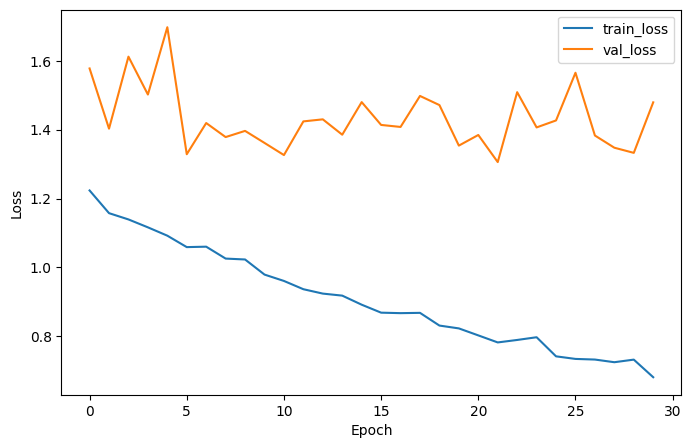

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="train_loss")
plt.plot(val_losses, label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


In [19]:
from torch.utils.data import DataLoader

test_loader = DataLoader(
    dataset_test,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


import torch

def evaluate_accuracy(model, dataloader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total


In [20]:
acc1 = evaluate_accuracy(model1, test_loader, device)


print(f"MyCNN1 test acc: {acc1:.4f}")


MyCNN1 test acc: 0.6131


### **analysis of model 1**

## **model 2**

### **analysis of model 2**